# Módulo 1: EDA e Classificação de Condição do Motor

#### Objetivo: Demonstrar fundamentos de análise exploratória de dados industriais, engenharia de features em sinais vibro-acústicos e classificação multiclasse de falhas.
#### Tarefa
- Realizar análise exploratória dos sinais fornecidos (domínio do tempo e/ou frequência);
- Implementar um pipeline de extração de features a partir das séries temporais dos
sensores;
- Treinar e comparar 2 modelos de classificação das 4 classes de condição do motor;
- Avaliar os modelos com métricas adequadas ao problema e discutir os resultados.

In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
from eda_functionc import *
from features_extraction import *
from classification import *

### Análise Exploratória dos Sinais - EDA

Nesta etapa, o mais importante é compreender as características dos sinais em relação a:
- diferenças entre as quatro condições do motor;
- diferenças entre os perfis componente afetado, velocidade e carga;
- perfis estatísticas dos dados.

Resumo dos arquivos:
   filename   class_name speed     load
H_H_1_0.csv      Healthy 15 Hz Unloaded
H_H_1_1.csv      Healthy 15 Hz   Loaded
H_H_3_0.csv      Healthy 45 Hz Unloaded
H_H_3_1.csv      Healthy 45 Hz   Loaded
R_U_1_0.csv    Unbalance 15 Hz Unloaded
R_U_1_1.csv    Unbalance 15 Hz   Loaded
R_U_3_0.csv    Unbalance 45 Hz Unloaded
R_U_3_1.csv    Unbalance 45 Hz   Loaded
R_M_1_0.csv Misalignment 15 Hz Unloaded
R_M_1_1.csv Misalignment 15 Hz   Loaded
R_M_3_0.csv Misalignment 45 Hz Unloaded
R_M_3_1.csv Misalignment 45 Hz   Loaded
B_R_1_0.csv  Bowed rotor 15 Hz Unloaded
B_R_1_1.csv  Bowed rotor 15 Hz   Loaded
B_R_3_0.csv  Bowed rotor 45 Hz Unloaded
B_R_3_1.csv  Bowed rotor 45 Hz   Loaded


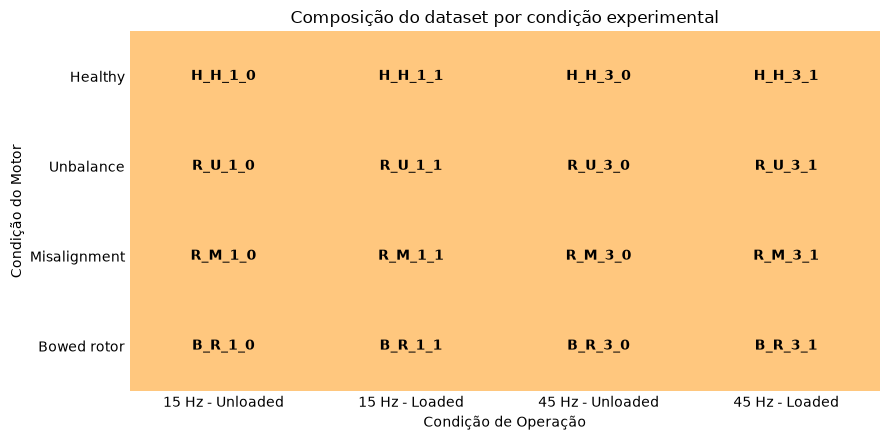

In [2]:
## Leitura e análise inicial dos dados

DATA_DIR = Path("/home/luisachristina/Desktop/FIEPE/dataset_desafio")


metadata = build_metadata_table(DATA_DIR)

print("Resumo dos arquivos:")
print(metadata[["filename", "class_name", "speed", "load"]].to_string(index=False))

plot_experimental_design(metadata)

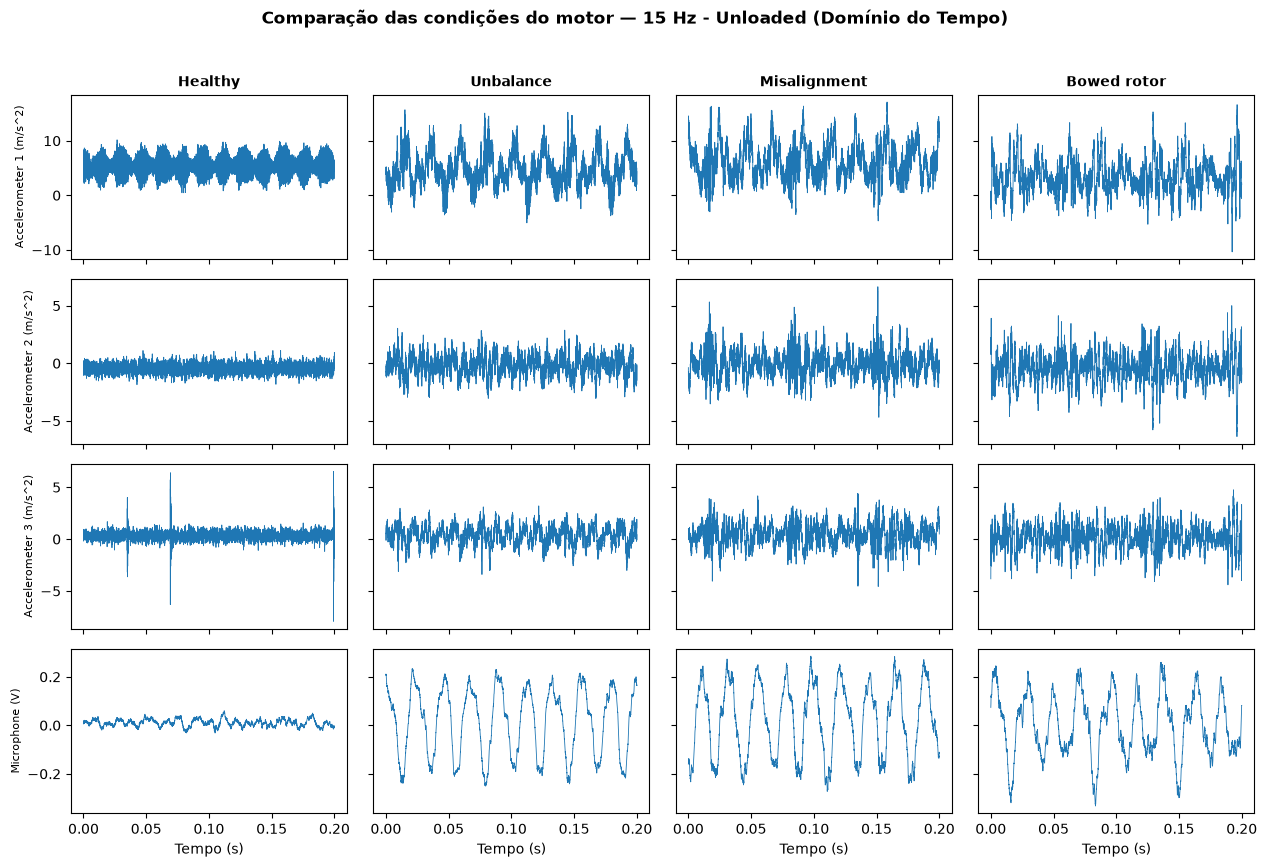

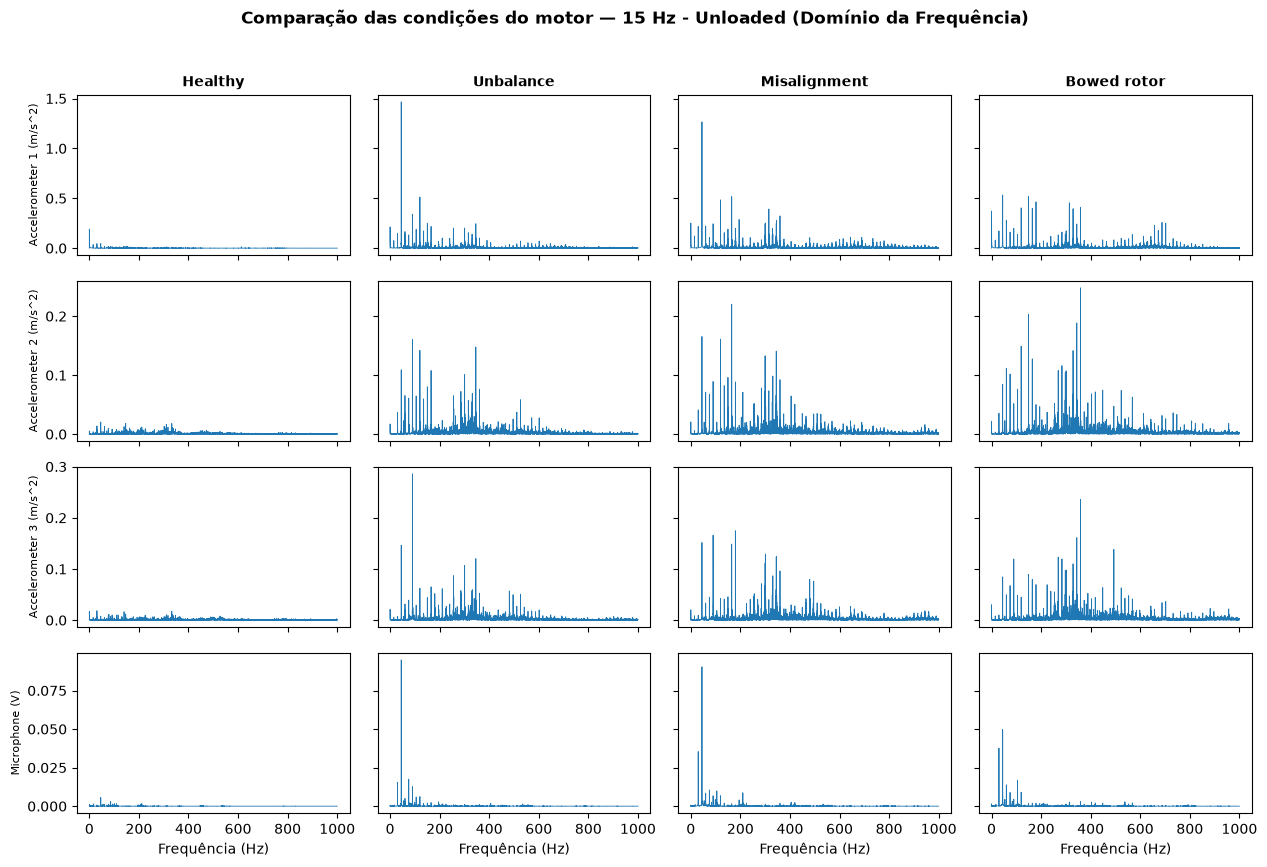

In [3]:
"""
Análise das quatro condições do motor no domínio de tempo e frequência
Condições de operação a serem escolhidas para analisar a condição do motor:
    "15 Hz - Unloaded"
    "15 Hz - Loaded"
    "45 Hz - Unloaded"
    "45 Hz - Loaded"
"""

plot_condition_comparison(metadata, "15 Hz - Unloaded", domain="time")
plot_condition_comparison(metadata, "15 Hz - Unloaded", domain="frequency", max_freq=1000)



Com o objetivo de análisar os quatro estados do motor (classes), foi selecionada inicialmente a condição de operação "15 Hz - Unloaded", permitindo comparar as classes sob uma mesma velocidade nominal e condição de carga. Na análise do dominio do tempo usamos uma janela de 0.20 segundos para visualizar as diferenças dos perfis dos sinais nas diferentes condições do motor. Enquanto isto, na análise no domínio da frequência, foi utilizado o sinal inteiro, aplicando a Transformada de Fourier após a remoção da componente média do sinal, considerando apenas as frequências positivas e a taxa de amostragem de 42 kHz, em seguida, a magnitude espectral foi normalizada pelo número total de amostras.

No domínio do tempo, observa-se que as quatro condições apresentam perfis distintos nos diferentes canais de aquisição. O motor saudável apresenta, de modo geral, menor variabilidade nos sinais dos Acelerômetros 2 e 3 e menor amplitude no sinal do microfone. Em contrapartida, as condições de falha do morot apresentam maiores oscilações e amplitude mais pronunciadas. O Acelerômetro 1 apresenta comportamento distinto dos demais canais, aspecto que deve ser interpretado considerando sua maior susceptibilidade ao ruído elétrico proveniente do inversor de frequência.

No domínio da frequência, a separação entre a condição saudável e as condições de falha torna-se ainda mais evidente. O motor saudável apresenta espectro predominantemente concentrado em componentes de baixa amplitude, enquanto os estados de desbalanceamento, desalinhamento e rotor empenado apresentam maior conteúdo espectral e múltiplos picos distribuídos ao longo da faixa analisada. Além disso, as três condições de falha exibem padrões espectrais distintos entre si, tanto em relação às frequências dominantes quanto às respectivas magnitudes.

A temperatura não foi avaliada pois apresenta um padrão diferente do observada nos sinais dos acelerômetros e do microfone, com variações mais lentas.


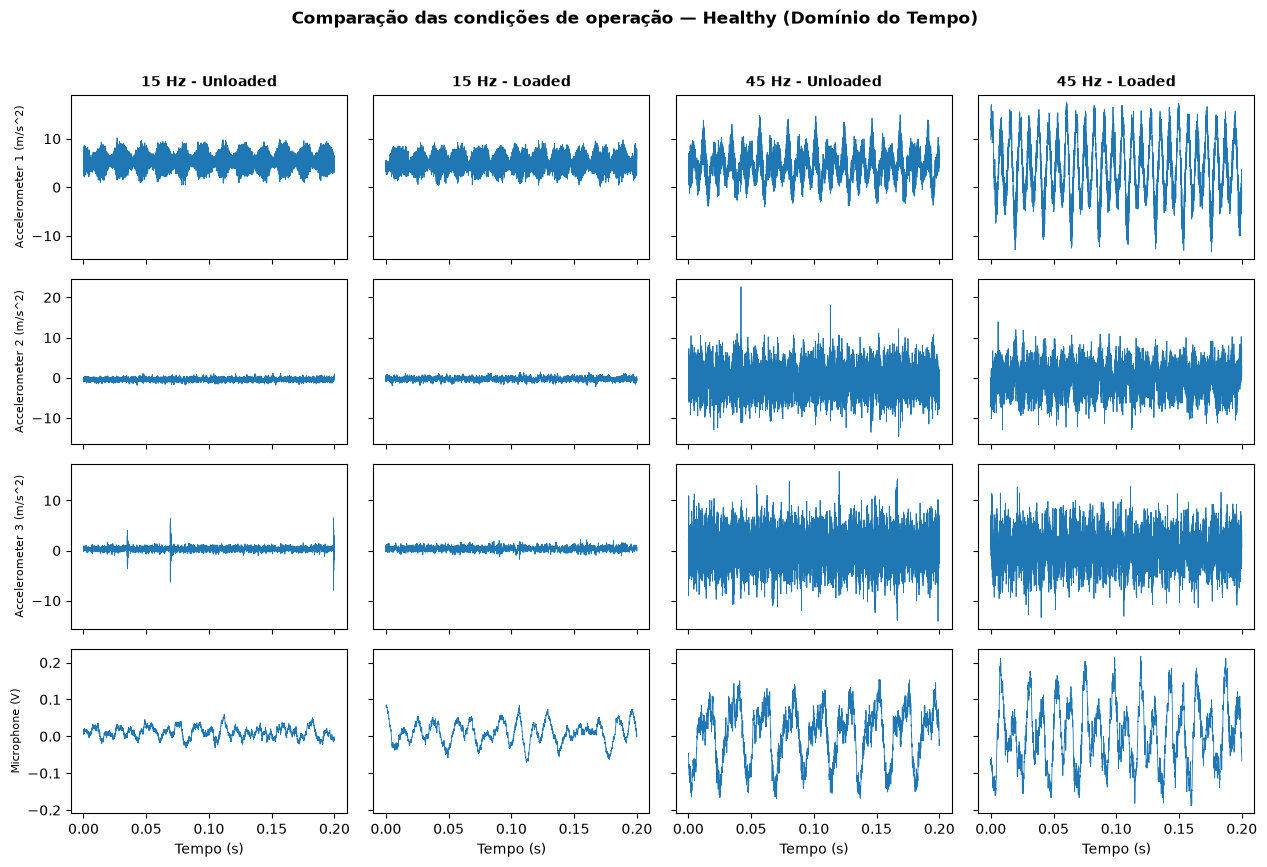

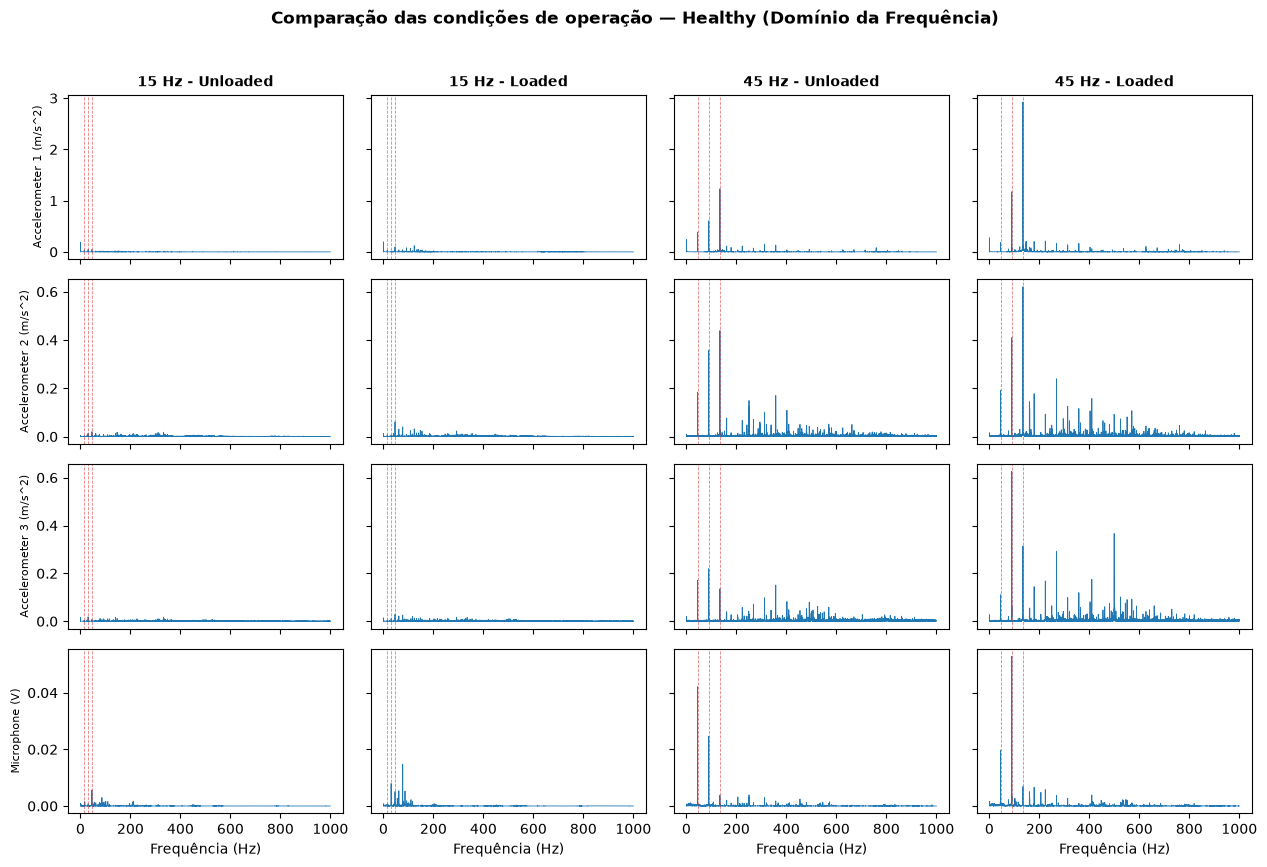

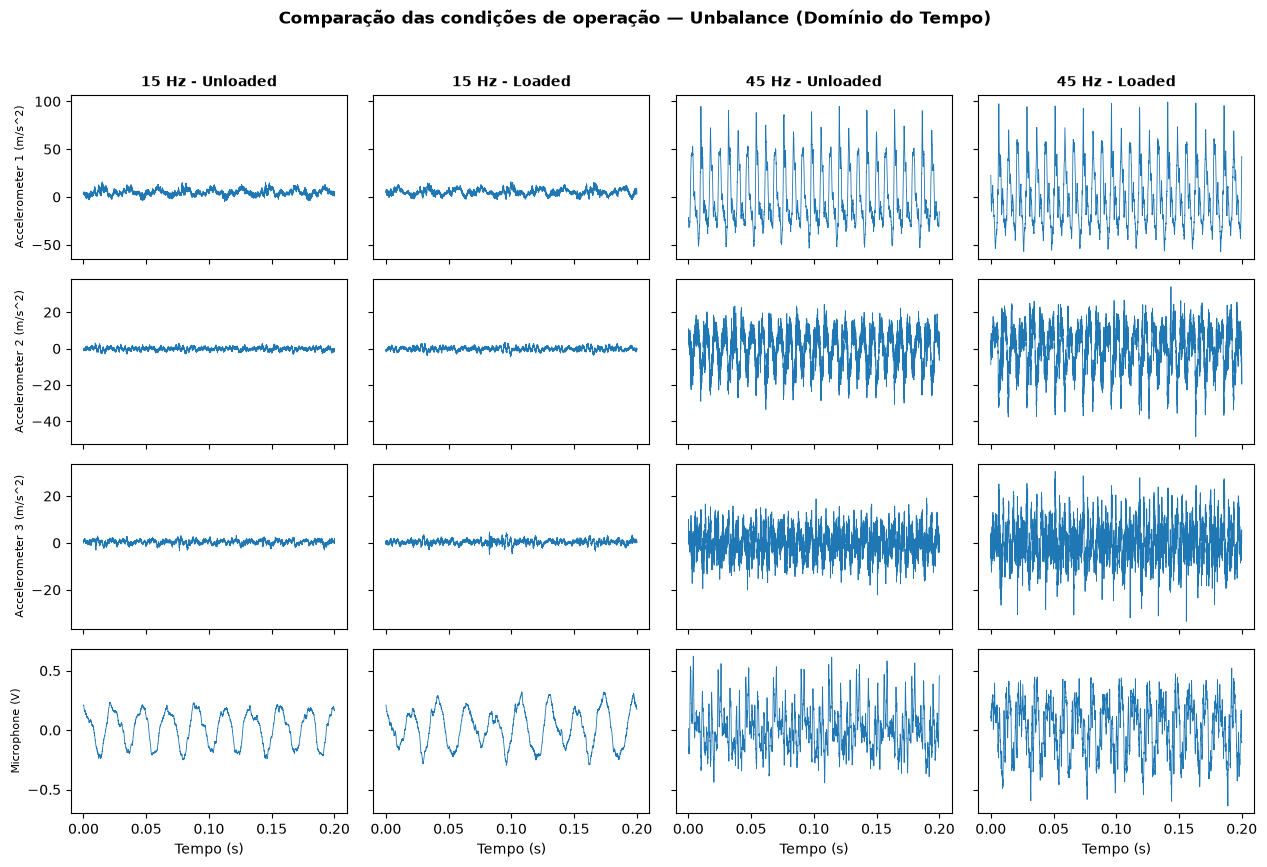

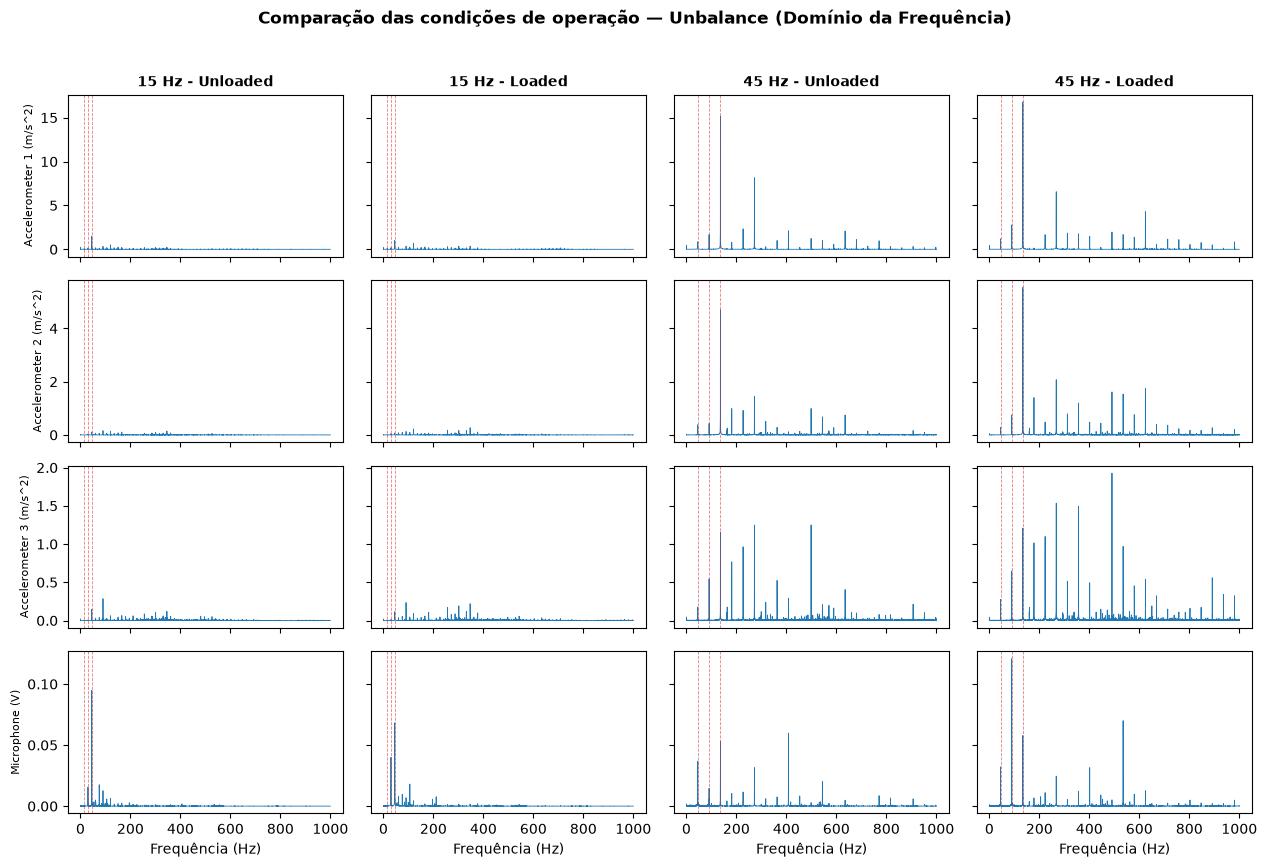

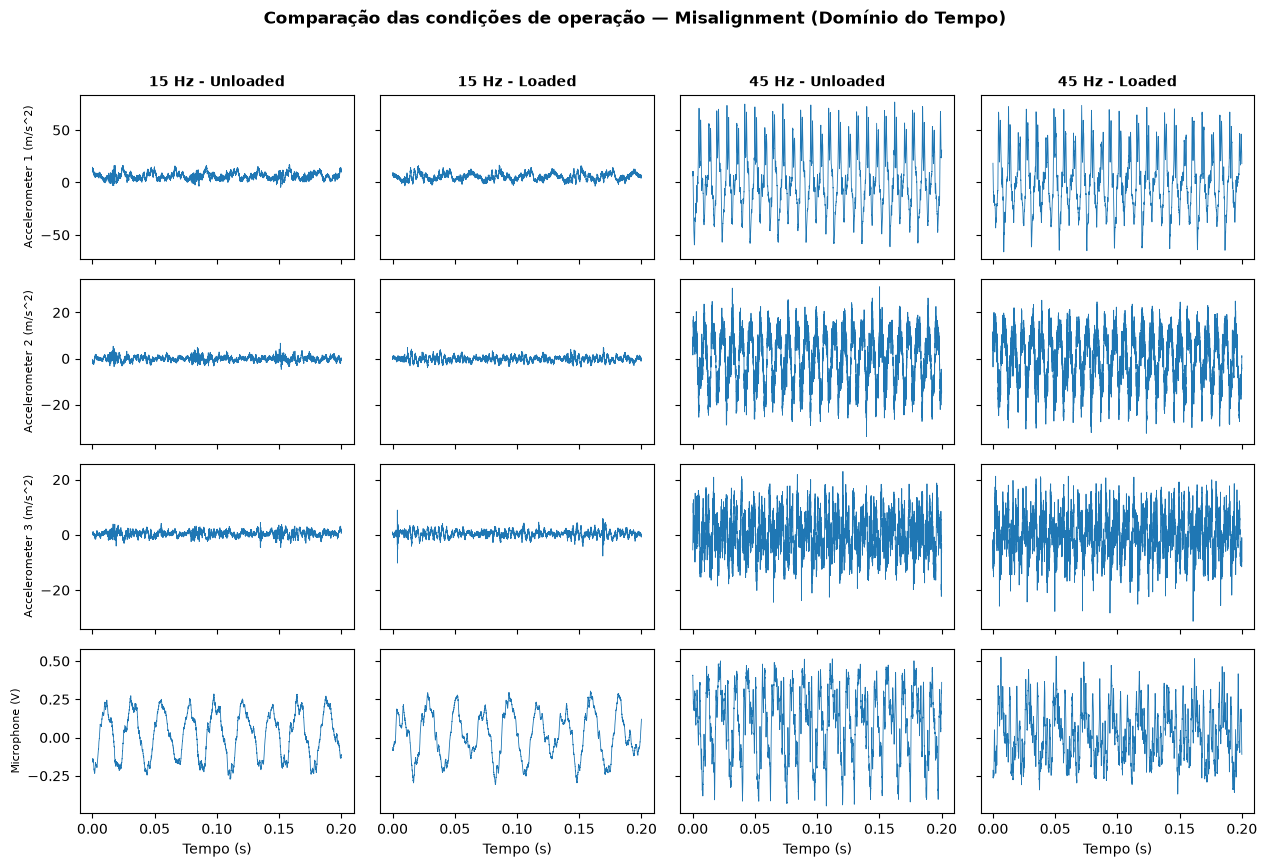

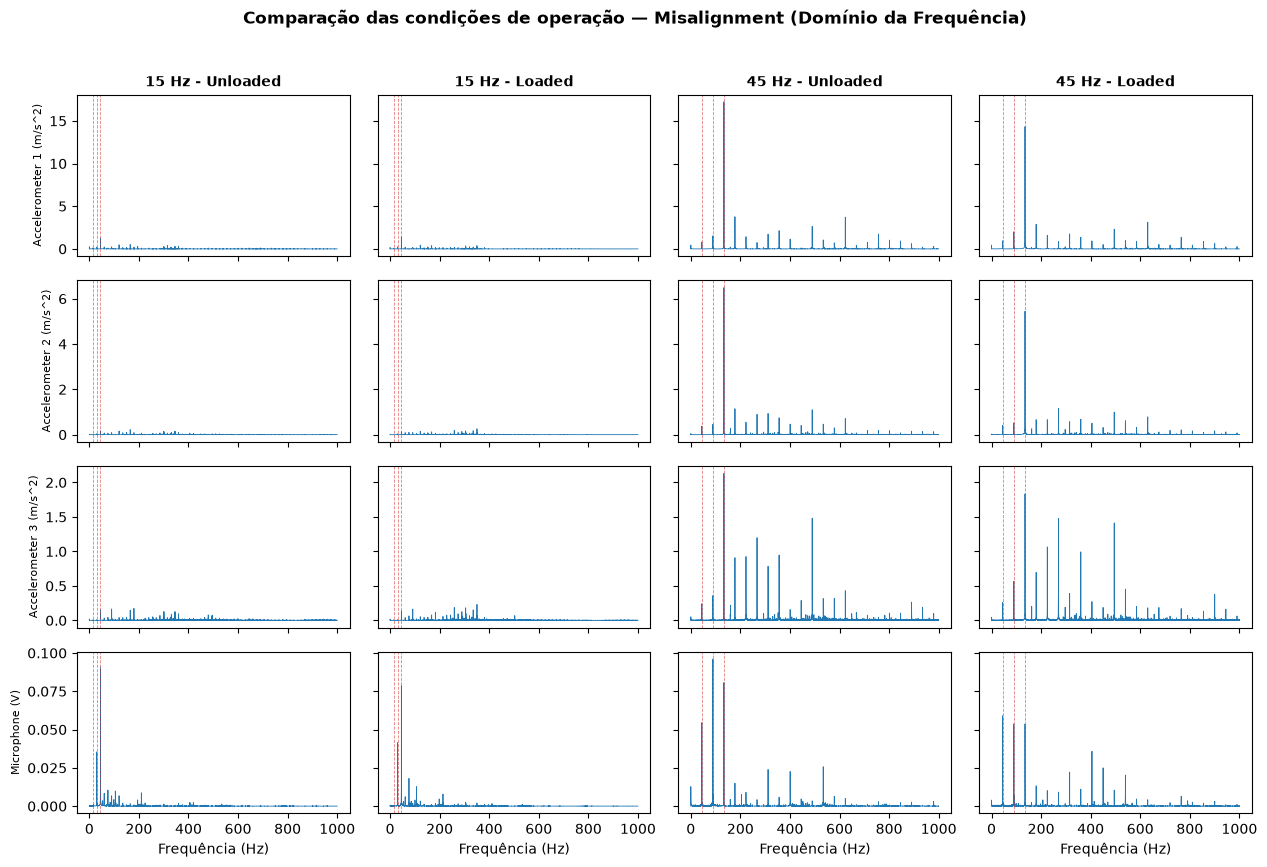

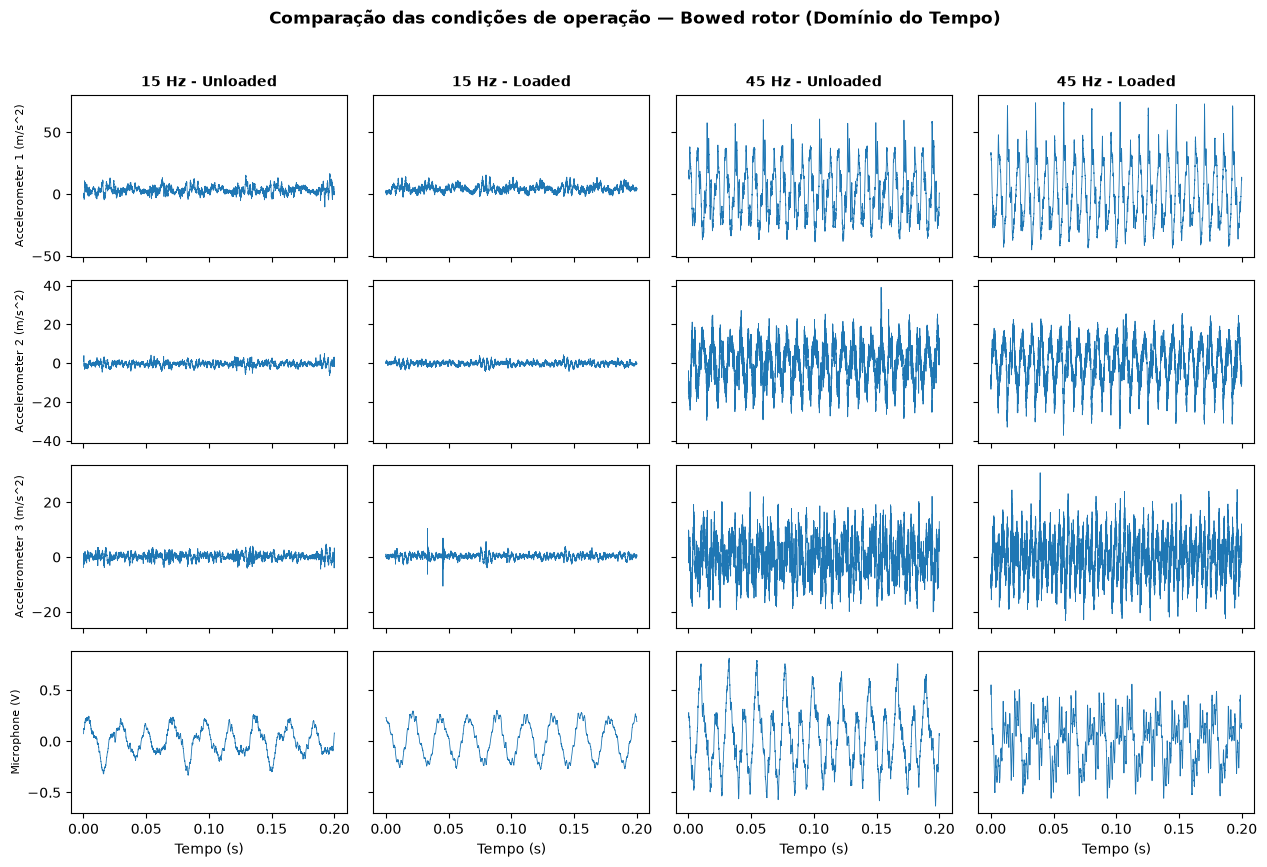

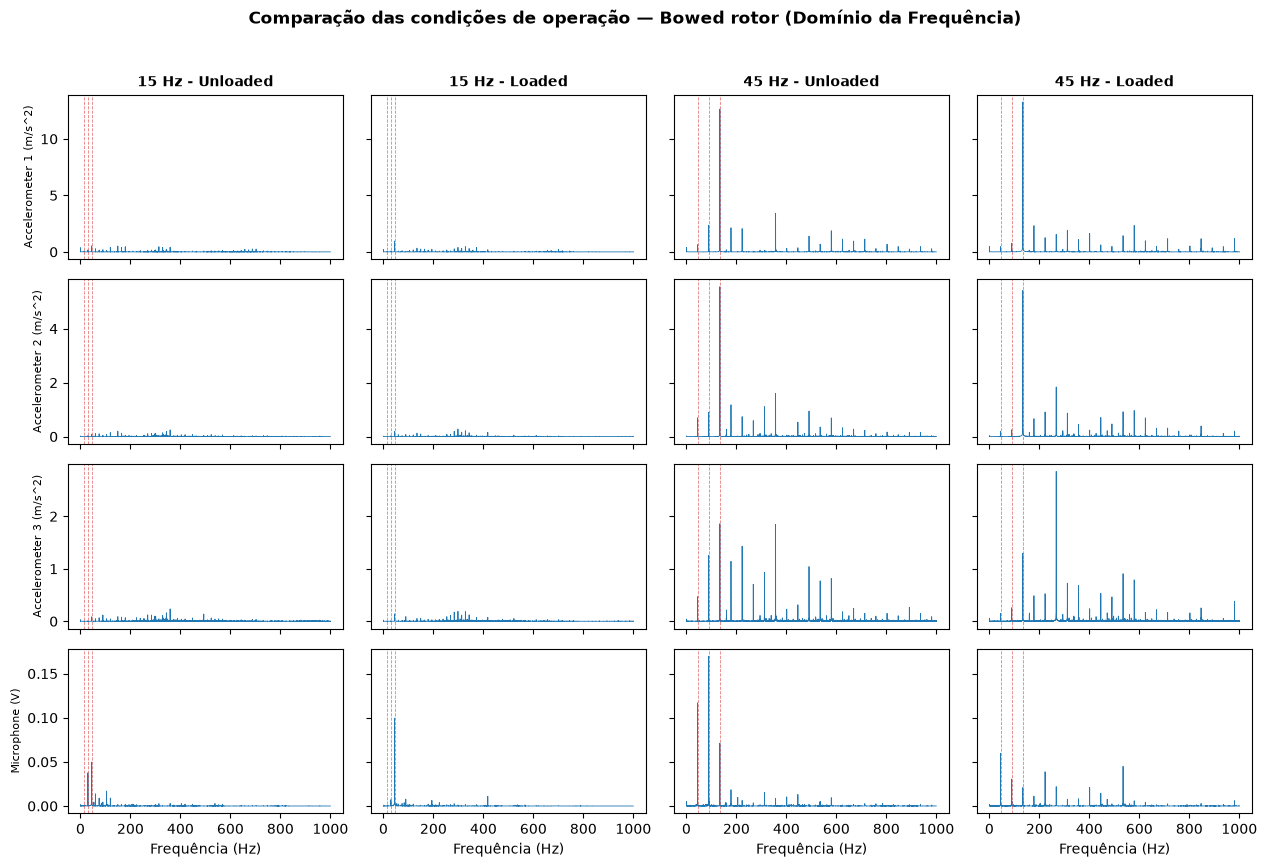

In [4]:
""" Análise das diferenças entre as condições de operação
condição do motor a ser escolhida para analisar as condições de operação:
"Healthy"
"Unbalance"
"Misalignment"
"Bowed rotor"
"""
plot_operating_condition_comparison(metadata, "Healthy", domain="time")
plot_operating_condition_comparison(metadata, "Healthy", domain="frequency", max_freq=1000)

plot_operating_condition_comparison(metadata, "Unbalance", domain="time")
plot_operating_condition_comparison(metadata, "Unbalance", domain="frequency", max_freq=1000)

plot_operating_condition_comparison(metadata, "Misalignment", domain="time")
plot_operating_condition_comparison(metadata, "Misalignment", domain="frequency", max_freq=1000)

plot_operating_condition_comparison(metadata, "Bowed rotor", domain="time")
plot_operating_condition_comparison(metadata, "Bowed rotor", domain="frequency", max_freq=1000)

De forma geral, a velocidade de operação apresentou mais impacto sobre os sinais do que a condição de carga. Para todas as classes, as aquisições em 45 Hz exibiram maiores amplitudes no domínio do tempo e maior conteúdo espectral quando comparadas às aquisições em 15 Hz. Em conjunto, os resultados indicam que velocidade, carga e tipo de falha influenciam simultaneamente as assinaturas vibroacústicas, sendo a velocidade o fator operacional visualmente mais relevante nas condições avaliadas. Essas diferenças reforçam a necessidade de considerar as condições de operação durante a extração e seleção de features para classificação.

In [5]:
"""
Estatísticas descritivas e qualidade dos dados:
Para cada arquivo e canal foram calculadas medidas no domínio do tempo, incluindo média, desvio padrão, RMS, 
valores mínimo e máximo, amplitude pico a pico, assimetria, curtose e fator de crista. 
"""
# Estatísticas
stats_df = compute_signal_statistics(metadata)
stats_df.groupby(["class_name", "channel"], observed=True).mean(numeric_only=True)

mean        std        rms  \
class_name   channel                                                   
Healthy      Accelerometer 1 (m/s^2)  5.424586   3.180111   6.541429   
             Accelerometer 2 (m/s^2) -0.450733   2.004537   2.105722   
             Accelerometer 3 (m/s^2)  0.379717   1.899953   1.993564   
             Microphone (V)           0.010237   0.054674   0.056442   
Unbalance    Accelerometer 1 (m/s^2)  4.593462  17.719689  19.506426   
             Accelerometer 2 (m/s^2) -0.251934   6.092325   6.107191   
             Accelerometer 3 (m/s^2)  0.346744   4.021780   4.075357   
             Microphone (V)           0.011991   0.190540   0.191012   
Misalignment Accelerometer 1 (m/s^2)  5.480050  16.316102  18.486976   
             Accelerometer 2 (m/s^2) -0.022356   6.197925   6.205029   
             Accelerometer 3 (m/s^2)  0.415376   4.229416   4.282339   
             Microphone (V)           0.025769   0.194352   0.196196   
Bowed rotor  Accelerometer 1 (m/s^2)  4.309781  13.082633  14.655343   
             Accelerometer 2 (m/s^2) -0.323781   5.874777   5.906174   
             Accelerometer 3 (m/s^2)  0.292850   4.137613   4.171136   
             Microphone (V)           0.011947   0.198871   0.199260   

                                            min        max  peak_to_peak  \
class_name   channel                                                       
Healthy      Accelerometer 1 (m/s^2)  -5.623877  15.364307     20.988184   
             Accelerometer 2 (m/s^2) -20.252735  23.230849     43.483583   
             Accelerometer 3 (m/s^2) -21.469792  18.153059     39.622852   
             Microphone (V)           -0.167609   0.169706      0.337315   
Unbalance    Accelerometer 1 (m/s^2) -30.698463  59.637792     90.336256   
             Accelerometer 2 (m/s^2) -25.797998  29.565994     55.363993   
             Accelerometer 3 (m/s^2) -28.981690  30.984548     59.966239   
             Microphone (V)           -0.459543   0.504883      0.964427   
Misalignment Accelerometer 1 (m/s^2) -36.678966  51.102265     87.781231   
             Accelerometer 2 (m/s^2) -27.119835  36.553998     63.673833   
             Accelerometer 3 (m/s^2) -37.750944  39.439472     77.190416   
             Microphone (V)           -0.484947   0.502745      0.987692   
Bowed rotor  Accelerometer 1 (m/s^2) -26.773256  48.224851     74.998107   
             Accelerometer 2 (m/s^2) -26.007558  23.158309     49.165866   
             Accelerometer 3 (m/s^2) -24.419744  22.924568     47.344312   
             Microphone (V)           -0.493086   0.525601      1.018686   

                                      skewness   kurtosis  crest_factor  
class_name   channel                                                     
Healthy      Accelerometer 1 (m/s^2) -0.026896  -0.392837      2.311483  
             Accelerometer 2 (m/s^2)  0.015215   0.573780      9.377191  
             Accelerometer 3 (m/s^2) -0.285732  36.440130     20.274648  
             Microphone (V)          -0.105345  -0.473498      3.336080  
Unbalance    Accelerometer 1 (m/s^2)  0.421234  -0.441171      2.873759  
             Accelerometer 2 (m/s^2) -0.321658  -0.058889      5.072911  
             Accelerometer 3 (m/s^2) -0.066241   2.594104     13.065614  
             Microphone (V)           0.048135  -0.800777      2.702325  
Misalignment Accelerometer 1 (m/s^2)  0.307832  -0.333054      2.827309  
             Accelerometer 2 (m/s^2) -0.065051   0.117561      6.200160  
             Accelerometer 3 (m/s^2) -0.074476   1.619750     13.069693  
             Microphone (V)          -0.111583  -0.837874      2.639724  
Bowed rotor  Accelerometer 1 (m/s^2)  0.395133   0.088344      3.385583  
             Accelerometer 2 (m/s^2) -0.325929   0.564015      5.134876  
             Accelerometer 3 (m/s^2) -0.099982   1.596926     10.447767  
             Microphone (V)           0.007961  -0.660733      2.730586

In [6]:
# Qualidade
quality_df = check_signal_quality(metadata)

quality_df.sort_values("pct_at_extreme_value", ascending=False).head(10)

,filename,class_name,condition,channel,n_missing,pct_missing,pct_at_extreme_value
26,R_U_1_1.csv,Unbalance,15 Hz - Loaded,Microphone (V),0,0.0,0.000952
19,H_H_3_1.csv,Healthy,45 Hz - Loaded,Temperature (Celsius),0,0.0,0.000952
6,H_H_1_1.csv,Healthy,15 Hz - Loaded,Microphone (V),0,0.0,0.000714
4,H_H_1_0.csv,Healthy,15 Hz - Unloaded,Temperature (Celsius),0,0.0,0.000714
30,R_U_3_0.csv,Unbalance,45 Hz - Unloaded,Accelerometer 1 (m/s^2),0,0.0,0.000714
24,R_U_1_0.csv,Unbalance,15 Hz - Unloaded,Temperature (Celsius),0,0.0,0.000714
14,H_H_3_0.csv,Healthy,45 Hz - Unloaded,Temperature (Celsius),0,0.0,0.000714
10,H_H_3_0.csv,Healthy,45 Hz - Unloaded,Accelerometer 1 (m/s^2),0,0.0,0.000714
54,R_M_3_0.csv,Misalignment,45 Hz - Unloaded,Temperature (Celsius),0,0.0,0.000714
79,B_R_3_1.csv,Bowed rotor,45 Hz - Loaded,Temperature (Celsius),0,0.0,0.000714


Não foram identificados valores ausentes relevantes nos canais analisados. A proporção de amostras coincidentes com os extremos observados também foi avaliada como uma verificação preliminar de saturação. Esses resultados foram considerados antes das etapas subsequentes de caracterização dos sinais.

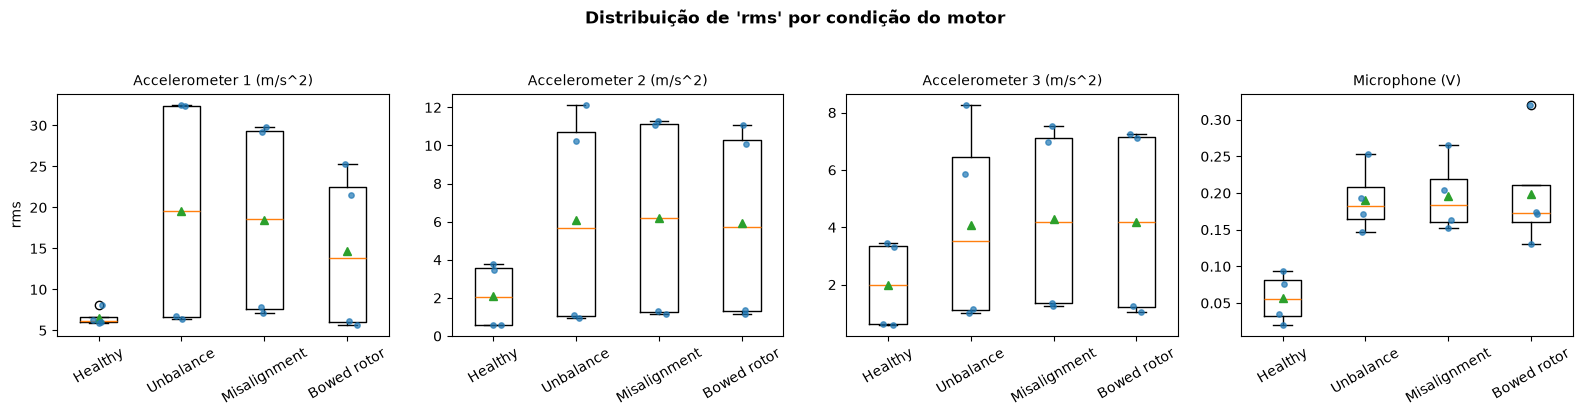

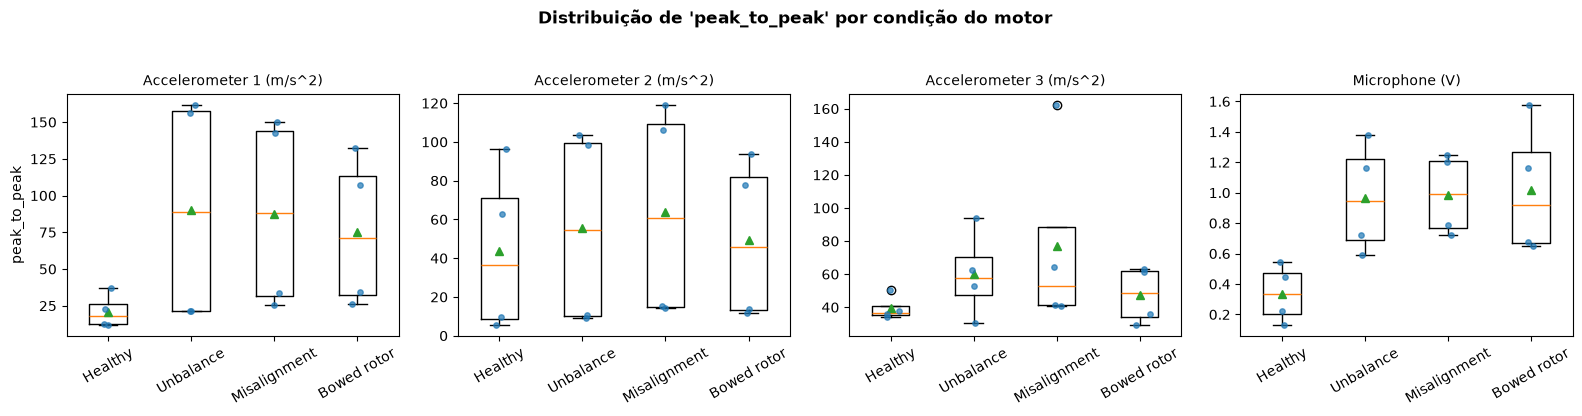

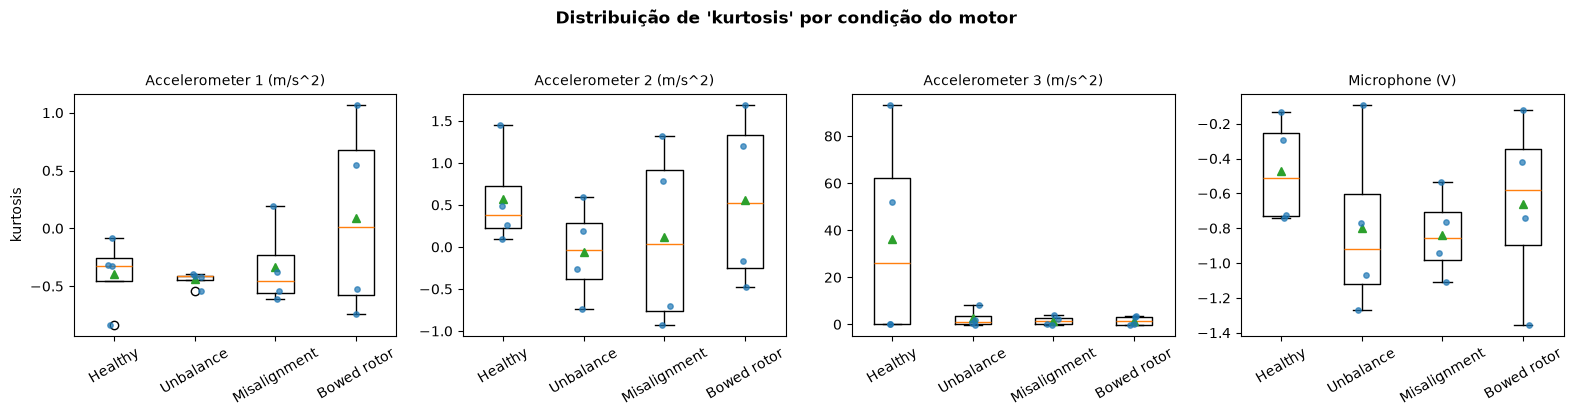

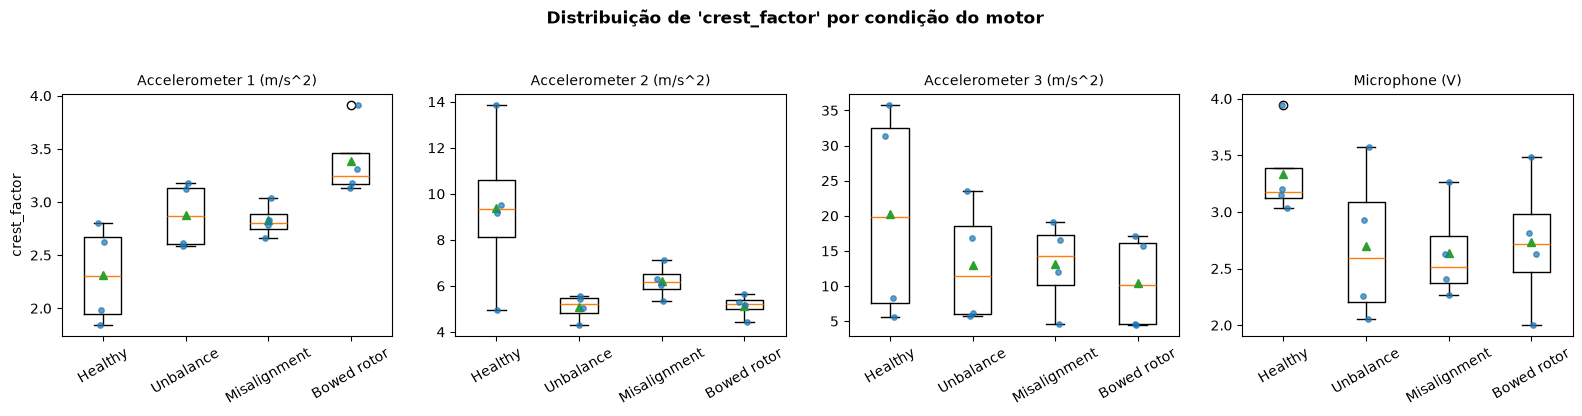

In [7]:
# Comparação das estatísticas entre condições do motor
plot_statistics_by_class(stats_df, metric="rms")
plot_statistics_by_class(stats_df, metric="peak_to_peak")
plot_statistics_by_class(stats_df, metric="kurtosis")
plot_statistics_by_class(stats_df, metric="crest_factor")


Foram selecionados RMS, amplitude pico a pico, fator de crista e curtose como descritores estatísticos dos sinais, por caracterizarem propriedades complementares relevantes ao monitoramento de máquinas rotativas. O RMS fornece uma medida da energia global do sinal e permite avaliar alterações na intensidade da vibração. A amplitude pico a pico representa a excursão total observada durante a aquisição, sendo sensível a variações de grande amplitude. O fator de crista, definido pela razão entre o valor de pico e o RMS, complementa essas medidas ao quantificar a presença de picos em relação ao nível energético global do sinal. Por fim, a curtose caracteriza o comportamento das caudas da distribuição e é sensível à ocorrência de componentes impulsivas ou valores extremos. 

REFERÊNCIA:
Tiboni, M.; Remino, C.; Bussola, R.; Amici, C. A Review on Vibration-Based Condition Monitoring of Rotating Machinery. Appl. Sci. 2022, 12, 972. https://doi.org/10.3390/app12030972



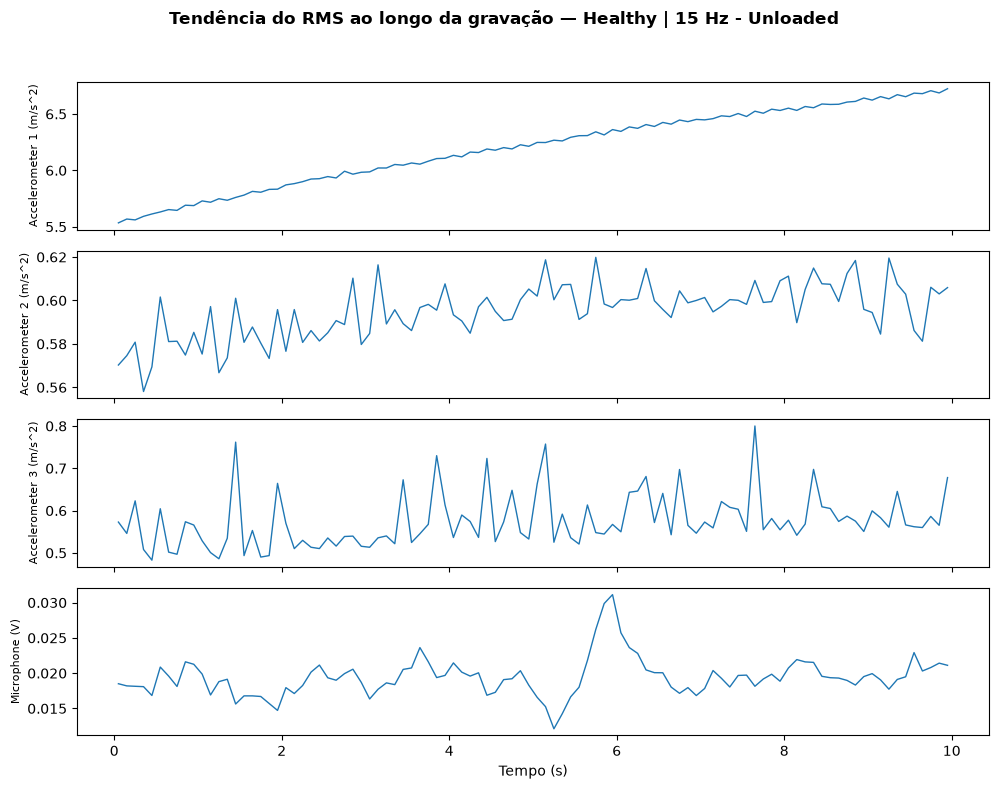

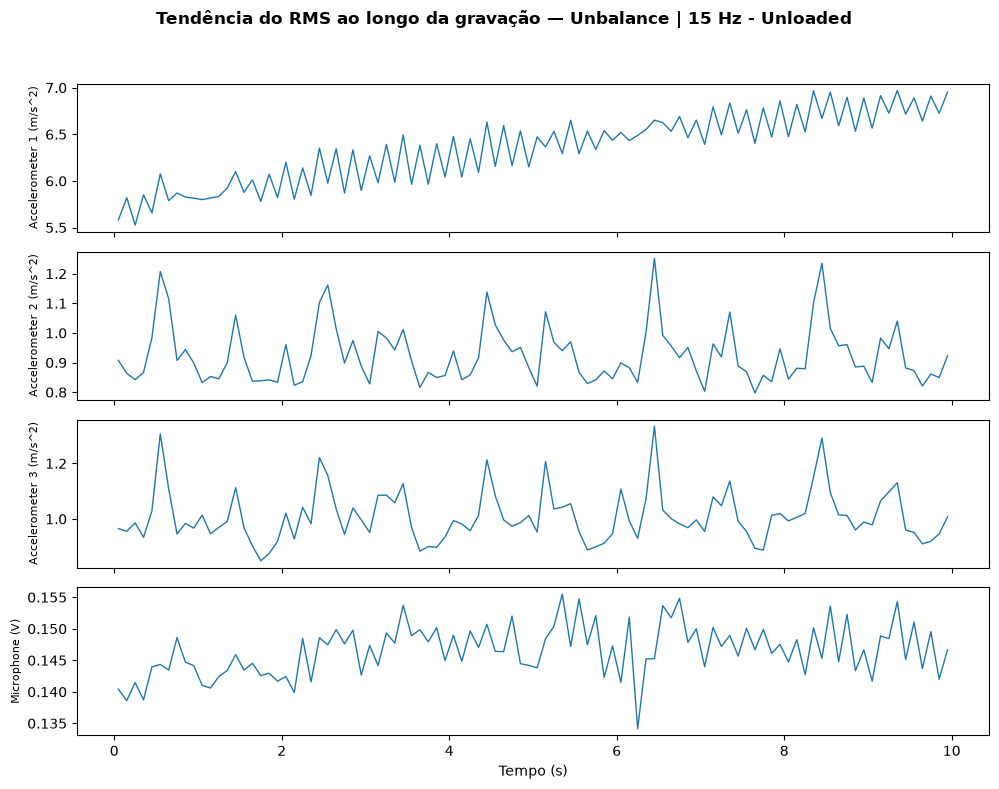

In [8]:
# Análise da estabilidade temporal
plot_signal_trend(metadata, "Healthy", "15 Hz - Unloaded")
plot_signal_trend(metadata, "Unbalance", "15 Hz - Unloaded")

A análise do RMS ao longo da gravação permite observar como a intensidade do sinal varia com o tempo, em vez de resumir toda a aquisição em um único valor. Essa avaliação é útil para identificar mudanças graduais, oscilações recorrentes ou picos pontuais, além de auxiliar na definição posterior de uma estratégia de janelamento para a extração de features.

Nas condições analisadas, tanto o motor saudável quanto o desbalanceado apresentam alguma variação do RMS ao longo dos 10 segundos. No acelerômetro 1, observa-se uma tendência de aumento progressivo em ambos os casos, embora o sinal de Unbalance apresente oscilações mais evidentes, isso pode estar relacionado a suscetibilidade ao ruído elétrico, como descrito no dicionário de dados. Nos acelerômetro 2 e 3, o motor saudável mantém comportamento mais estável, enquanto a condição de desbalanceamento apresenta maior variabilidade e picos recorrentes. O microfone também mostra uma diferença clara entre as condições, com valores de RMS mais elevados para Unbalance.

### Extração de Features

Nesta etapa, o objetivo é transformar os sinais brutos em descritores que representem características relevantes para a classificação, considerando:

- definição da estratégia de janelamento dos sinais;

- particionamento dos dados (train/test);

- extração de features no domínio do tempo;

- extração de features no domínio da frequência;

- avaliação da capacidade discriminativa e da redundância entre as features extraídas.

In [ ]:
# Estratégia de janelamento
features_df = extract_features(metadata, window_seconds=1.0, overlap=0.5)
feature_columns = get_feature_columns(features_df)

print("Shape:", features_df.shape)
print("Janelas por classe:")
print(features_df.groupby("class_name", observed=True).size())
print("\nNúmero de features candidatas:", len(feature_columns))

features_df.head()


Shape: (304, 64)
Janelas por classe:
class_name
Healthy         76
Unbalance       76
Misalignment    76
Bowed rotor     76
dtype: int64

Número de features candidatas: 56


,filename,class_name,speed,load,condition,window_id,start_time,end_time,accelerometer_1__mean,accelerometer_1__std,...,microphone__skewness,microphone__kurtosis,microphone__crest_factor,microphone__harmonic_1x_magnitude,microphone__harmonic_2x_magnitude,microphone__harmonic_3x_magnitude,microphone__spectral_energy,microphone__spectral_centroid,microphone__spectral_entropy,microphone__dominant_frequency
0,H_H_1_0.csv,Healthy,15 Hz,Unloaded,15 Hz - Unloaded,0,0.0,1.0,5.392087,1.577060,...,-0.017238,-0.367084,3.159606,0.000247,0.000586,0.005646,0.000106,135.184955,5.138496,46.0
1,H_H_1_0.csv,Healthy,15 Hz,Unloaded,15 Hz - Unloaded,1,0.5,1.5,5.478274,1.574192,...,0.108463,-0.330383,3.146194,0.000149,0.000789,0.005725,0.000105,141.815288,5.049219,46.0
2,H_H_1_0.csv,Healthy,15 Hz,Unloaded,15 Hz - Unloaded,2,1.0,2.0,5.556896,1.574671,...,0.153140,-0.110640,3.471150,0.000157,0.000995,0.005372,0.000096,141.240392,5.484988,46.0
3,H_H_1_0.csv,Healthy,15 Hz,Unloaded,15 Hz - Unloaded,3,1.5,2.5,5.636245,1.592920,...,0.132797,-0.129534,3.382400,0.000235,0.000985,0.005388,0.000109,127.742651,5.263831,46.0
4,H_H_1_0.csv,Healthy,15 Hz,Unloaded,15 Hz - Unloaded,4,2.0,3.0,5.712105,1.601565,...,0.125376,-0.260515,3.950620,0.000118,0.000684,0.006873,0.000135,120.219725,4.616483,46.0


Cada gravação  de 10s é segmentada em janelas de 1 segundo com 42.000 amostras, também foi usado com 50% de sobreposição, gerando 19 janelas por arquivo (304 no total, 76 por classe). 

In [ ]:
# Particionamento dos dados: nested K-Fold sem vazamento
nested_splits = nested_group_kfold_splits(features_df, group_column="filename", outer_k=4, inner_k=3)

print(f"{len(nested_splits)} folds externos (nenhum AssertionError = sem vazamento entre arquivos)\n")

for i, fold in enumerate(nested_splits):
    test_files = sorted(features_df.iloc[fold["outer_test_idx"]]["filename"].unique())
    print(f"Fold externo {i}: {len(fold['outer_train_idx'])} janelas treino | {len(fold['outer_test_idx'])} janelas teste | arquivos de teste: {test_files}")


4 folds externos (nenhum AssertionError = sem vazamento entre arquivos)

Fold externo 0: 228 janelas treino | 76 janelas teste | arquivos de teste: ['B_R_1_0.csv', 'H_H_1_0.csv', 'R_M_3_0.csv', 'R_U_1_1.csv']
Fold externo 1: 228 janelas treino | 76 janelas teste | arquivos de teste: ['B_R_1_1.csv', 'H_H_3_0.csv', 'R_M_3_1.csv', 'R_U_3_1.csv']
Fold externo 2: 228 janelas treino | 76 janelas teste | arquivos de teste: ['B_R_3_0.csv', 'H_H_1_1.csv', 'R_M_1_0.csv', 'R_U_1_0.csv']
Fold externo 3: 228 janelas treino | 76 janelas teste | arquivos de teste: ['B_R_3_1.csv', 'H_H_3_1.csv', 'R_M_1_1.csv', 'R_U_3_0.csv']


O dataset tem apenas 4 arquivos por classe (uma gravação por combinação velocidade×carga). Como cada arquivo vira várias janelas, a partição  agrupa por filename para que  janelas da mesma gravação nunca fiquem em lados diferentes do split, senão o modelo veria características daquela gravação específica no treino e teste ao mesmo tempo, causando vazamento de dados.

Usamos 'StratifiedGroupKFold' (grupo = arquivo, estratificado por classe) em dois níveis:
- outer_k=4: cada fold externo reserva para teste 1 arquivo por classe (4 no total)
- inner_k=3: dentro do treino de cada fold externo (12 arquivos, 3 por classe), reserva 1 arquivo por classe para validação

'nested_group_kfold_splits' valida internamente que não há sobreposição de arquivos entre nenhum par treino/teste ou treino/validação.

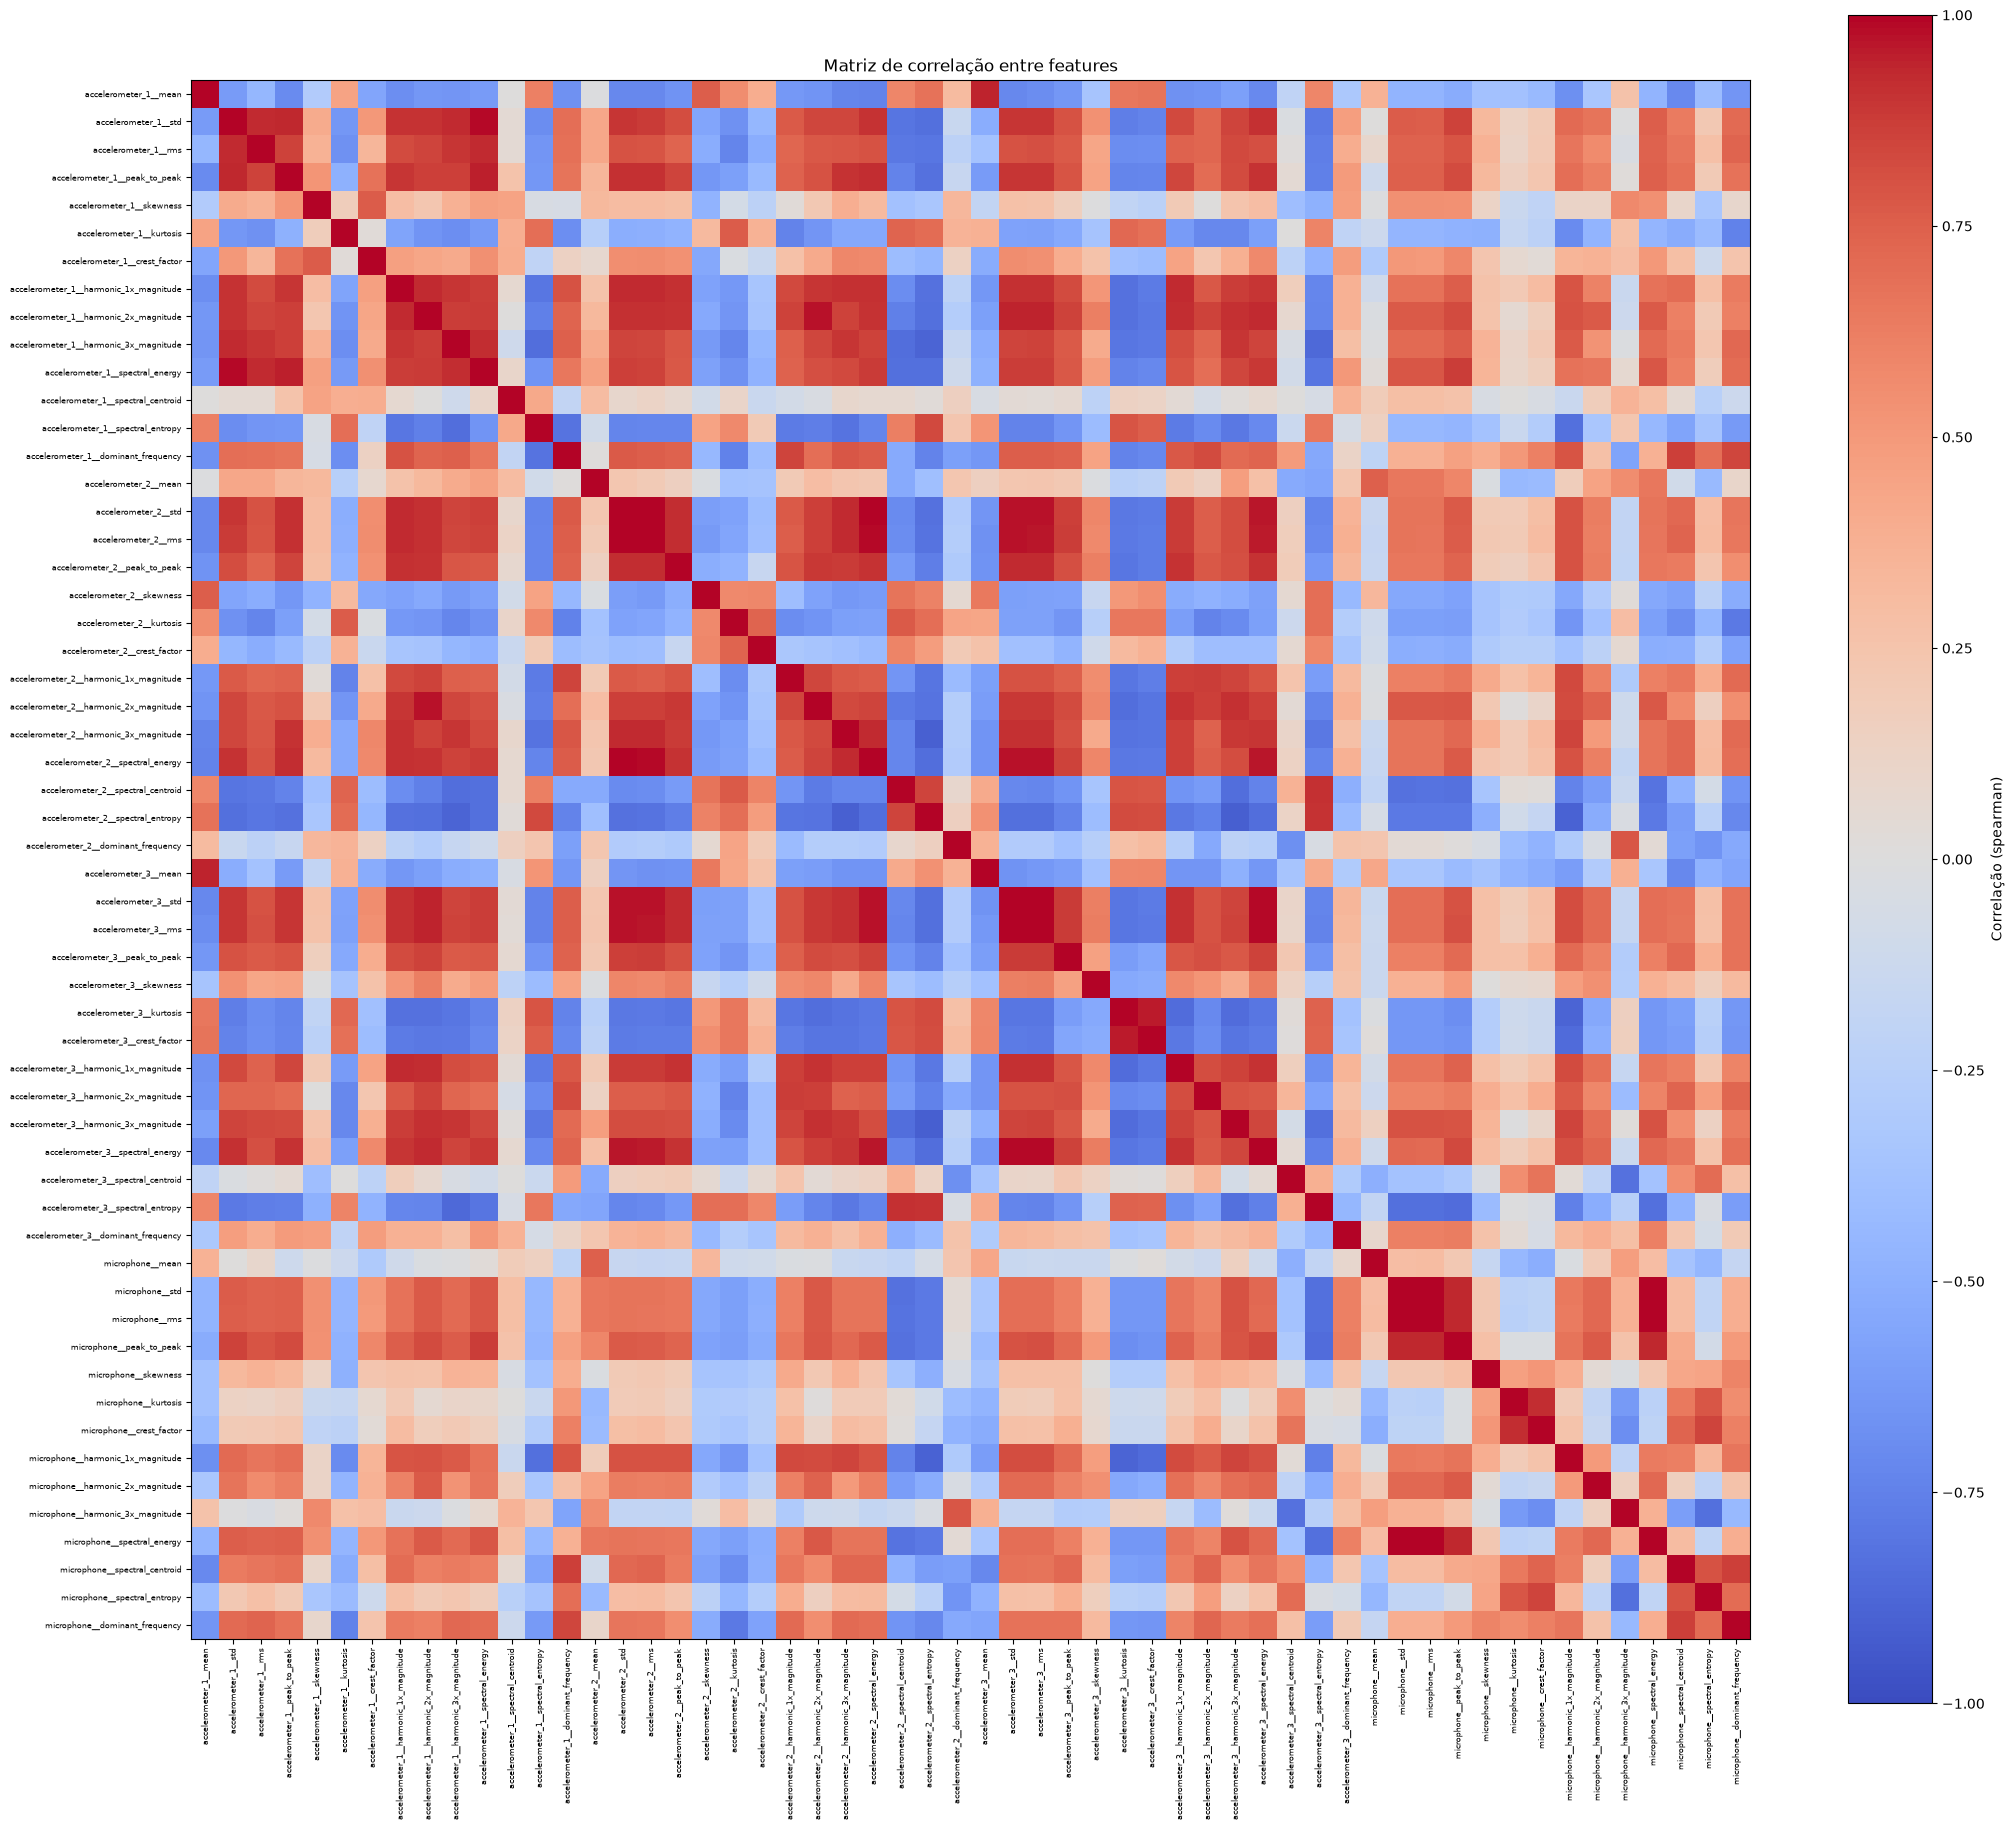

78 pares de features com |correlação| >= 0.9


,feature_a,feature_b,correlation
0,microphone__std,microphone__spectral_energy,0.999968
1,microphone__rms,microphone__spectral_energy,0.999733
2,microphone__std,microphone__rms,0.999707
3,accelerometer_3__std,accelerometer_3__rms,0.998213
4,accelerometer_2__std,accelerometer_2__rms,0.995456
5,accelerometer_2__std,accelerometer_2__spectral_energy,0.993633
6,accelerometer_3__std,accelerometer_3__spectral_energy,0.992051
7,accelerometer_3__rms,accelerometer_3__spectral_energy,0.991872
8,accelerometer_1__std,accelerometer_1__spectral_energy,0.991434
9,accelerometer_2__rms,accelerometer_2__spectral_energy,0.989435


In [ ]:
# Redundância entre features
plot_feature_correlation(features_df, feature_columns=feature_columns)

redundant_pairs = find_redundant_feature_pairs(features_df, feature_columns=feature_columns, threshold=0.9)
print(f"{len(redundant_pairs)} pares de features com |correlação| >= 0.9")
redundant_pairs.head(15)


Manter as 56 features pode não ser ideal, isto porque 78 pares têm correlação ≥ 0.9, e como o dataset contém poucas amostras (4 por condição de motor), features redundantes só aumentam o risco de overfitting sem agregar informação. Assim, serão mantidas apenas aquelas que não estiverem fortemente correlacionadas (|corr| ≥ 0.9) com alguma já selecionada.


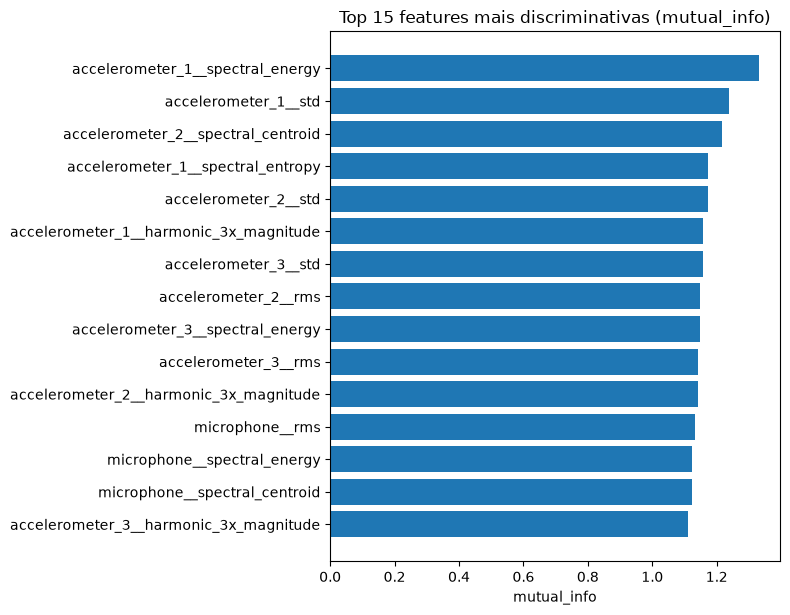

,feature,f_value,p_value,mutual_info
0,accelerometer_1__spectral_energy,29.256608,1.276120e-16,1.329957
1,accelerometer_1__std,26.628225,2.683587e-15,1.237947
2,accelerometer_2__spectral_centroid,94.755837,3.656615e-43,1.217634
3,accelerometer_1__spectral_entropy,6.287213,3.773249e-04,1.174146
4,accelerometer_2__std,16.317980,7.527071e-10,1.171856
5,accelerometer_1__harmonic_3x_magnitude,25.595662,9.026050e-15,1.157550
6,accelerometer_3__std,12.234149,1.421897e-07,1.156131
7,accelerometer_2__rms,15.776155,1.495381e-09,1.148471
8,accelerometer_3__spectral_energy,22.909446,2.213891e-13,1.147362
9,accelerometer_3__rms,12.113663,1.663536e-07,1.142850


In [20]:
# Capacidade discriminativa das features
discriminability_df = evaluate_feature_discriminability(features_df, feature_columns=feature_columns)
plot_feature_discriminability(discriminability_df, top_n=15, metric="mutual_info")
discriminability_df.head(15)

Foram avaliadas, para cada uma das 56 features candidatas, o quanto ela separa as quatro classes através de ANOVA F-value (relação linear) e informação mútua (captura também relações não-lineares). Esse teste mostra que há várias features com potencial discriminativo entre as quatro classes. A partir deles podemos inferir que a informação relevante não está concentrada em um único sensor nem em um único domínio. Entre as 15 features mais bem ranqueadas aparecem os três acelerômetros e o microfone, assim como descritores temporais, como RMS e desvio padrão, e espectrais, como energia, centroide, entropia e magnitude do terceiro harmônico. Isso significa que a utilização conjunta de features temporais e espectrais é adequada na classificação.

In [ ]:
# Seleção do conjunto final de features
selected_features = select_uncorrelated_features(
    features_df, feature_columns=feature_columns, discriminability_df=discriminability_df, threshold=0.9
)

print(f"Features selecionadas: {len(selected_features)} de {len(feature_columns)}")
for feature in selected_features:
    print(" -", feature)


Features selecionadas: 34 de 56
 - accelerometer_1__spectral_energy
 - accelerometer_2__spectral_centroid
 - accelerometer_1__spectral_entropy
 - accelerometer_2__std
 - microphone__rms
 - microphone__spectral_centroid
 - accelerometer_3__harmonic_3x_magnitude
 - accelerometer_1__skewness
 - accelerometer_3__dominant_frequency
 - accelerometer_3__harmonic_1x_magnitude
 - microphone__harmonic_3x_magnitude
 - accelerometer_2__skewness
 - accelerometer_3__spectral_centroid
 - accelerometer_1__spectral_centroid
 - accelerometer_1__kurtosis
 - accelerometer_2__kurtosis
 - accelerometer_2__dominant_frequency
 - accelerometer_2__harmonic_1x_magnitude
 - microphone__harmonic_2x_magnitude
 - accelerometer_3__kurtosis
 - accelerometer_1__crest_factor
 - microphone__spectral_entropy
 - accelerometer_2__mean
 - microphone__kurtosis
 - microphone__skewness
 - accelerometer_3__harmonic_2x_magnitude
 - microphone__harmonic_1x_magnitude
 - microphone__mean
 - microphone__dominant_frequency
 - accelero

### Classificação das condições do motor

As features extraídas dos sinais são usadas para classificar as quatro condições do motor. Comparamos dois modelos com estratégias de decisão diferentes:

- Random Forest, baseado em um conjunto de árvores de decisão;
- Support Vector Machine (SVM) com kernel RBF, baseado na construção de fronteiras não lineares no espaço de features.

A validação reaproveita o 'nested_group_kfold_splits' já construído na seção anterior: janelas do mesmo arquivo nunca ficam em conjuntos diferentes, evitando vazamento entre treino e teste.


In [14]:
from classification import (
    train_and_compare_models, summarize_nested_cv_results, per_class_report,
    aggregate_confusion_matrix, plot_confusion_matrix, plot_model_comparison,
    plot_metric_by_fold, MODEL_REGISTRY
)


In [ ]:
# Treino e busca de hiperparâmetros
all_results = train_and_compare_models(features_df, selected_features, nested_splits)

summary_df = summarize_nested_cv_results(all_results)
summary_df


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,roc_auc_macro_mean,roc_auc_macro_std,pr_auc_macro_mean,pr_auc_macro_std
0,Random Forest,0.401316,0.088020,0.376389,0.081093,0.365150,0.086533,0.401316,0.088020,0.636629,0.127387,0.517344,0.101726
1,SVM (kernel RBF),0.365132,0.115974,0.315148,0.065256,0.295833,0.046211,0.365132,0.115974,0.596549,0.074134,0.429414,0.024496


In [ ]:
# Métricas dos modelos por fold
for model_key, fold_results in all_results.items():
    print(MODEL_REGISTRY[model_key]["label"])
    for r in fold_results:
        print(f"  fold {r['fold']}: f1_macro={r['f1_macro']:.3f}  accuracy={r['accuracy']:.3f}  pr_auc_macro={r['pr_auc_macro']:.3f}  roc_auc_macro={r['roc_auc_macro']:.3f}  best_params={r['best_params']}")
    print()


Random Forest
  fold 0: f1_macro=0.417  accuracy=0.500  pr_auc_macro=0.610  roc_auc_macro=0.763  best_params={'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1}
  fold 1: f1_macro=0.328  accuracy=0.342  pr_auc_macro=0.444  roc_auc_macro=0.596  best_params={'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1}
  fold 2: f1_macro=0.486  accuracy=0.474  pr_auc_macro=0.624  roc_auc_macro=0.742  best_params={'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 4}
  fold 3: f1_macro=0.275  accuracy=0.289  pr_auc_macro=0.391  roc_auc_macro=0.446  best_params={'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 4}

SVM (kernel RBF)
  fold 0: f1_macro=0.386  accuracy=0.461  pr_auc_macro=0.418  roc_auc_macro=0.576  best_params={'C': 10, 'gamma': 0.01}
  fold 1: f1_macro=0.250  accuracy=0.250  pr_auc_macro=0.399  roc_auc_macro=0.495  best_params={'C': 10, 'gamma': 0.001}
  fold 2: f1_macro=0.375  accuracy=0.500  pr_auc_macro=0.466  roc_auc_macro=0.701  best_par

In [ ]:
# Relatório por classe e matriz de confusão
print("Random Forest")
print(per_class_report(all_results["random_forest"]))
print()
print("SVM (kernel RBF)")
print(per_class_report(all_results["svm_rbf"]))


Random Forest
              precision    recall  f1-score     support
Healthy        1.000000  1.000000  1.000000   76.000000
Unbalance      0.298507  0.263158  0.279720   76.000000
Misalignment   0.087500  0.092105  0.089744   76.000000
Bowed rotor    0.234568  0.250000  0.242038   76.000000
accuracy       0.401316  0.401316  0.401316    0.401316
macro avg      0.405144  0.401316  0.402876  304.000000
weighted avg   0.405144  0.401316  0.402876  304.000000

SVM (kernel RBF)
              precision    recall  f1-score     support
Healthy        1.000000  1.000000  1.000000   76.000000
Unbalance      0.216216  0.210526  0.213333   76.000000
Misalignment   0.208791  0.250000  0.227545   76.000000
Bowed rotor    0.000000  0.000000  0.000000   76.000000
accuracy       0.365132  0.365132  0.365132    0.365132
macro avg      0.356252  0.365132  0.360220  304.000000
weighted avg   0.356252  0.365132  0.360220  304.000000


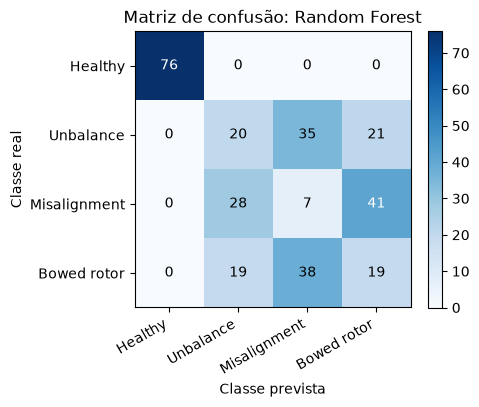

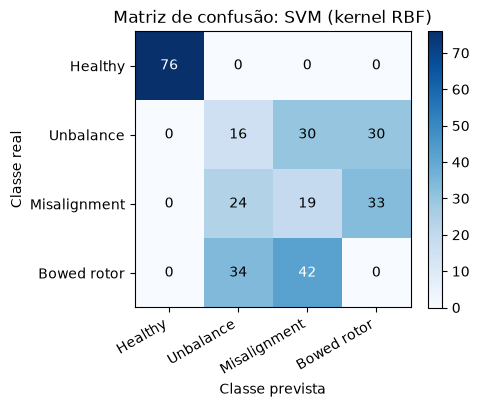

In [19]:
plot_confusion_matrix(aggregate_confusion_matrix(all_results["random_forest"]), title="Matriz de confusão: Random Forest")
plot_confusion_matrix(aggregate_confusion_matrix(all_results["svm_rbf"]), title="Matriz de confusão: SVM (kernel RBF)")


Atraveś das MC, podemos observar que os modelos não conseguem distinguir entre as classes Bowed rotor e Misalignment, classificando, no dois casos, mais amostras de Bowed rotor como Misalignment do que como Bowed rotor, sendo o inverso também verdadeiro. Unbalanced também tem mais amostras erroneamente classificadas como as outras classes de falha, do que como a classe real. Apenas a condição de motor Healthy, que alcançou 100% de acurácia, consequentemente, teve todas as suas amostras corretamenter classificadas.
